<div align='center'>
<h1 style='font-size:38px;'>Grain Temperature Calculation</h1>
<h2 style='font-weight:400;'>Using <code>GrainStar</code> to derive equilibrium temperatures</h2>
<p><em>Thermal distance grid → temperature vs distance & size</em></p>
</div>

---
**Contents:**
1. Initialize grain and star
2. Load thermal distance grid
3. Examine temperature range
4. Interpolate temperatures
5. Plot profiles for selected sizes
6. Contour map size vs distance

## 1. Imports and object setup

In [2]:
from pyGrater import stargrains as stgr
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Create grain (loads Q tables) and star (loads spectrum + properties)
grain = stgr.Grain(redo_Q=False, composition='astroSi')
star = stgr.Star(star_name='HD113766')

# Initialize GrainStar (loads or computes thermal distance grid)
stargrain = stgr.GrainStar(grain, star, N_temp=1000, redo_therm_dist=True)

CREATING GRAIN OBJECT
Developper parameters file: /Users/prioletp/PhD/public_codes/pyGrater/pyGrater/parameters/developper_params.yaml
Grain composition: astroSi
astroSi optical tables already exist :
--> Wavelengths : 1000 values from 5.0e-02 to 2.0e+03 microns
--> Sizes : 600 values from 1.0e-02 to 3.0e+03 microns
CREATING STAR OBJECT
Star properties file: /Users/prioletp/PhD/public_codes/pyGrater/data/star_data/stars_main_properties.txt
Star name: 'HD113766'
The temperature is 6650.0 K
The logg is 4.02 cgs
The radius is 1.35 R_sun
The distance is 108.63 pc
The spectral type is F5
The normalization band is V
The apparent magnitude in V band is 8.08 mag
The stellar spectrum is binned by a factor of 20
The closest spectrum in the grid has T_eff = 6600.0 K and log(g) = 4.0 cgs
Normalizing in the full spectrum
Stellar spectrum loaded from 0.0199698417077793 to 3917.5988438313925 µm and normalized.
Normalized in V-band to 8.08 mag
The stellar luminosity is 5.69 m2 L_sun
CREATING STAR-GRAI

Computing thermal equilibrium distances: 100%|██████████| 1000/1000 [00:09<00:00, 107.60it/s]

Thermal distances saved to: /Users/prioletp/PhD/public_codes/pyGrater/data/temperatures/temperatures_astroSi_Tsub1500.0_starHD113766.npz


## 2. Thermal equilibrium distance
To calculate the temperature of dust grains, we first calculate the thermal equilibrium distance, $r(a,T_{\mathrm{d}})$, for a range of grain sizes and temperatures (i.e the distance at which a grain of certain size and temperature would be at thermal equilibrium).

It is calculated in the following way:
\begin{equation}
r(a,T_{\mathrm{d}})=\frac{d_{\star}}{2}\sqrt{\frac{\int_{\lambda}Q_{\mathrm{abs}}F_{\star}(\lambda)\mathrm{d}\lambda}{\int_{\lambda}Q_{\mathrm{abs}}\pi B_{\lambda}\left(T_{\mathrm{d}}\right)\mathrm{d}\lambda}}
\end{equation}
where F⋆(λ) is the stellar flux at Earth. 

In [5]:
therm_dist = stargrain.therm_dist          # shape: (n_sizes, n_T)
temp_range = stargrain.temp_range         # temperatures (K)
sizes = grain.Qabs_sizes                  # micron
print('Thermal distance grid shape:', therm_dist.shape)
print('Temperature range: {:.1f} – {:.1f} K'.format(temp_range.min(), temp_range.max()))
print('Size range: {:.3e} – {:.3e} µm'.format(sizes.min(), sizes.max()))
print('Distance range: {:.4f} – {:.1f} AU'.format(therm_dist.min(), therm_dist.max()))


Thermal distance grid shape: (600, 1000)
Temperature range: 3.0 – 1500.0 K
Size range: 1.000e-02 – 3.000e+03 µm
Distance range: 0.0848 – 2352026.0 AU


## 4. Interpolate temperatures at chosen distances

The r(a,Td) function is then numerically reversed to get Td(a,r). This is done using the `stargrain.get_temperature(distances)` to get equilibrium temperatures for all sizes at specified distances.

Source: Lebreton et al. 2013

In [6]:
distances = np.linspace(0.01, 10, 2000) #A range of r for the calculation of Td

temperatures = stargrain.get_temperature(distances)

print('Temperatures shape:', temperatures.shape)
print('Temperature range: {:.2f} – {:.2f} K'.format(temperatures.min(), temperatures.max()))



Temperatures shape: (600, 2000)
Temperature range: 121.81 – 1503.00 K


## 3. Visualize raw thermal distance grid
Rows: sizes; Columns: temperatures.

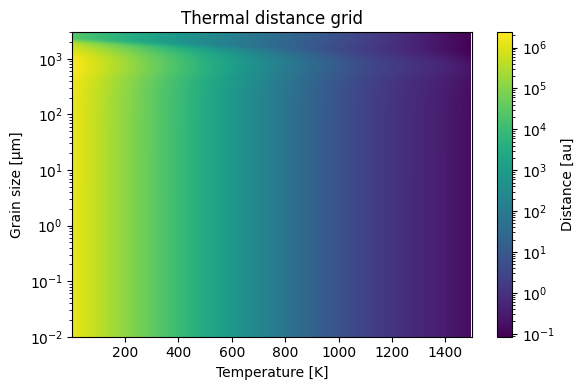

In [9]:
import matplotlib.colors as mcolors

plt.figure(figsize=(6,4))
plt.imshow(therm_dist, aspect='auto', origin='lower',
           extent=[temp_range.min(), temp_range.max(), sizes.min(), sizes.max()],
           norm=mcolors.LogNorm())
plt.colorbar(label='Distance [au]')
plt.xlabel('Temperature [K]')
plt.ylabel('Grain size [µm]')
plt.title('Thermal distance grid')
# plt.xscale('log')
plt.yscale('log')
plt.tight_layout()

## 5. Plot temperature vs distance for selected sizes

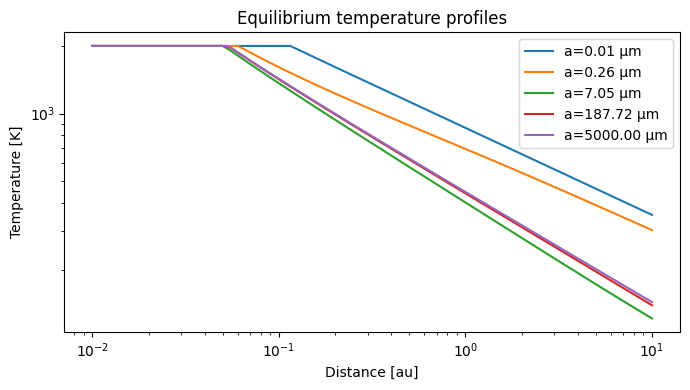

In [8]:
idx_sample = np.linspace(0, len(sizes)-1, 5, dtype=int)
plt.figure(figsize=(7,4))
for i in idx_sample:
    plt.loglog(distances, temperatures[i], label=f'a={sizes[i]:.2f} µm')
plt.xlabel('Distance [au]')
plt.ylabel('Temperature [K]')
plt.title('Equilibrium temperature profiles')
plt.legend()
plt.tight_layout()

## 6. Contour plot (size vs distance)
Log-size vs distance colored by temperature.

Be careful: To plot this you must have previously calculated the `stargrain.get_temperature` method

Plotting temperatures for sizes between 0.01 and 4999.999999999999 between distances 0.01 and 0.5


/Users/prioletp/PhD/public_codes/pyGrater/pyGrater/stargrains.py:959: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'$10^{{{int(y)}}}$' for y in yticks])


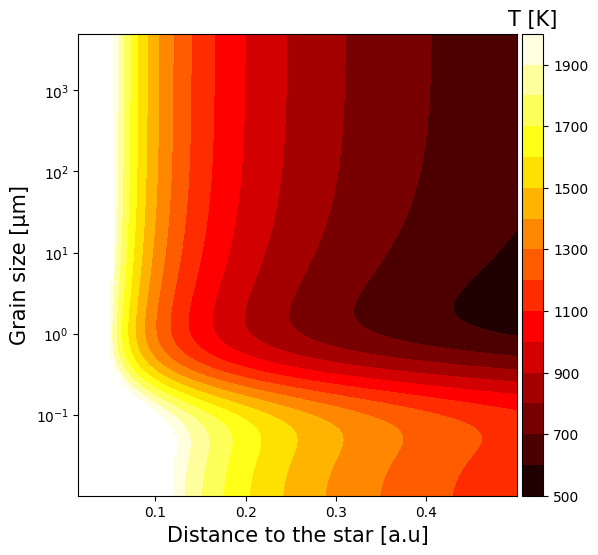

In [ ]:
cont: th, scattered
stargrain.plot_temperatures(min_size=None, max_size=None, min_dist=None, max_dist=0.5)

## 7. Notes
- Grid resolution controlled by `N_temp` in `GrainStar`.
- Sublimation temperature (`Tsub`) limits high-T region.
- Thermal distance grid cached on disk (NPZ) for reuse.
- Modify grain optical properties (sizes / wavelengths) via `general.yaml` then recompute.